In [1]:

#%%


import numpy as np
import matplotlib.pyplot as plt

# ======= PARAMETERS =======
N = 100
Nband = 10
size = 300
nk = 31
a = 20.0  # Å
kpoints = np.linspace(-0.0028, 0.0028, nk, endpoint=True)
emax_v_um = 3.0

# efields_um = np.array([0.05])

# Colormap from blue → red
# cmap = plt.cm.Blues
# colors = 'blue'#cmap(np.linspace(0.5, 1, len(efields_um)))

# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [3, 6],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})




def connect_kramers_partners(kx, lower_energy, upper_energy):
    """
    Connect a time-reversal-related pair across kx = 0.

    The input columns are energy ordered at every kx. Therefore,
    the physical branch identity must be exchanged across kx = 0.
    """

    negative_k = kx < 0.0
    zero_k = np.isclose(kx, 0.0, atol=1e-12)

    branch1 = np.where(
        negative_k,
        lower_energy,
        upper_energy
    )

    branch2 = np.where(
        negative_k,
        upper_energy,
        lower_energy
    )

    # Enforce their Kramers-degenerate meeting point at kx = 0.
    zero_energy = 0.5 * (
        lower_energy + upper_energy
    )

    branch1[zero_k] = zero_energy[zero_k]
    branch2[zero_k] = zero_energy[zero_k]

    return branch1, branch2





# ======= FUNCTION TO PLOT ON AXIS =======
def plot_bands(ax, direction, ylim, legend_loc, label, title):


    
    datafile = f"band_data_{direction}_E{emax_v_um:.3f}_size{size}_nk{nk}.dat"
    data = np.loadtxt(datafile)

    kx = data[:,0] * 1000
    valence1 = data[:, 1]
    valence2 = data[:, 2]

    valence_branch1, valence_branch2 = connect_kramers_partners(
            kx,
            valence1,
            valence2
        )
    

    


    datafile_pb = f"Pymablock_{direction}_EF{emax_v_um:.2f}_N{N}_L{size}.dat"
    data_pb = np.loadtxt(datafile_pb)

    kx_pb = data_pb[:,0] * 1000
    valence1_pb = data_pb[:, 1]
    valence2_pb = data_pb[:, 2]

    valence_branch1_pb, valence_branch2_pb = connect_kramers_partners(
            kx_pb,
            valence1_pb,
            valence2_pb
        )
    

    # Plot two nearby bands
    ax.plot(kx_pb, valence_branch1_pb , color='blue', lw=0.7, label = r'$\uparrow$ (P)')
    ax.plot(kx_pb, valence_branch2_pb , color='red', lw=0.7, label = r'$\downarrow$ (P)')
    # Plot two nearby bands
    ax.scatter(kx, valence_branch1 * 1e3 ,color='darkblue', s = 10, facecolor = 'w', label = r'$\uparrow$ (N)')
    ax.scatter(kx, valence_branch2 * 1e3 ,color='darkred', s = 10, facecolor = 'w', label = r'$\downarrow$ (N)')
    

    ax.axvline(0, color='black', linestyle='-', lw=0.8)
    # ax.axhline(0, color='black', linestyle='-', lw=0.8)
    # if ax == axs[0] or ax == axs[1]:
    #     ax.axvline(kpoints[int((nk-1)/2 + (nk-1)/4)], color='g', linestyle='--', lw=0.8)
        
    # if ax == axs[0] or ax == axs[1]:
    #     ax.axvline(kpoints[int((nk-1)/2 - (nk-1)/10)], color='g', linestyle='--', lw=0.8)
    
    # ax.set_xlim(-2, 2)
    # ax.set_ylim(*ylim)
    ax.set_xticks([-2, 0, 2])
    ax.tick_params(direction='in', length=6, width=0.8, colors='k',
                   bottom=True, top=True, left=True, right=True, labelsize=18)
    ax.set_ylabel('Energy (meV)', fontsize=18)
    # ax.set_title(title, fontsize=15)
    ax.legend(loc='lower center', ncol=2, title = r"$\mathcal{E}$"f"$_{direction}$={emax_v_um} V/$\mu$m""     $L = 30 $ nm",fontsize=13)
    


<>:129: SyntaxWarning: invalid escape sequence '\m'
<>:129: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_68885/895323466.py:129: SyntaxWarning: invalid escape sequence '\m'
  ax.legend(loc='lower center', ncol=2, title = r"$\mathcal{E}$"f"$_{direction}$={emax_v_um} V/$\mu$m""     $L = 30 $ nm",fontsize=13)


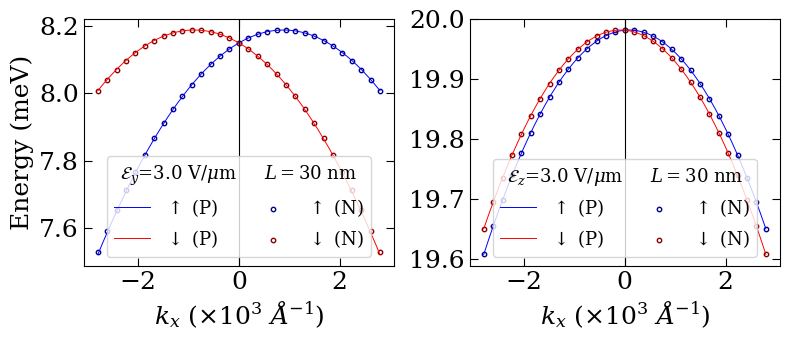

In [2]:

#---------------------------------------------
#  horizontal layout: 1 row, 2 columns
#---------------------------------------------

# ======= CREATE FIGURE (1×2) =======
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), layout="tight")

# 1️ Field along Y — Valence (LEFT)
plot_bands(axs[0], 'y',  (-6.25,-5.9), 'lower left', 'a', 'Top VB (E‖Y)')

# axs[0].text(0.025, 0.95, "(a)", transform=axs[0].transAxes, fontsize=16, va="top")

# 2️ Field along Z — Valence (RIGHT)
plot_bands(axs[1], 'z', (-6.15,-5.8), 'lower left', 'c', 'Top VB (E‖Z)')

# axs[1].text(0.025, 0.95, "(b)", transform=axs[1].transAxes, fontsize=16, va="top")
for ax in axs:
            ax.get_legend().get_title().set_fontsize(13)
# X label only once (centered visually)
axs[0].set_xlabel(r'$k_x$ ($\times$10$^3$ $\AA$$^{-1}$)', fontsize=18)
axs[1].set_xlabel(r'$k_x$ ($\times$10$^3$ $\AA$$^{-1}$)', fontsize=18)
axs[1].set_ylabel("")
axs[1].set_yticks([19.6,19.7,19.8,19.9, 20.0])
# axs[0].legend(fontsize=9, loc="best", handlelength=1.8)
# axs[1].legend(fontsize=9, loc="best", handlelength=1.8)

# ======= SAVE =======
fig.savefig("bands_electrci_field_horizontal.png", dpi=300)
fig.savefig("bands_electrci_field_horizontal.pdf")
fig.savefig("bands_electrci_field_horizontal.svg")
plt.show()